# Football2025 — Exploratory Data Analysis

This notebook analyses the RBK-AALESUND game dataset to understand class distribution,
object sizes, spatial patterns, and ball visibility. Findings directly inform model
and training choices.

In [1]:
from pathlib import Path
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_ROOT = Path("../data/RBK-AALESUND")
LABELS_DIR = DATA_ROOT / "labels" / "train"
ANNOTATIONS_XML = DATA_ROOT / "annotations.xml"

CLASS_NAMES = {0: "player", 1: "ball"}
CLASS_COLORS = {0: "#4C72B0", 1: "#DD8452"}

## 1. Load YOLO Labels

In [2]:
records = []  # (frame, class_id, cx, cy, w, h)

for label_file in sorted(LABELS_DIR.glob("*.txt")):
    frame = int(label_file.stem.split("_")[1])
    for line in label_file.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls, cx, cy, w, h = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        if cls in CLASS_NAMES:  # skip event_labels (class 2)
            records.append((frame, cls, cx, cy, w, h))

frames = np.array([r[0] for r in records])
classes = np.array([r[1] for r in records])
cx = np.array([r[2] for r in records])
cy = np.array([r[3] for r in records])
w  = np.array([r[4] for r in records])
h  = np.array([r[5] for r in records])

print(f"Total annotations: {len(records)}")
print(f"Total frames:      {len(set(frames))}")
print(f"Players:           {(classes == 0).sum()}")
print(f"Balls:             {(classes == 1).sum()}")

Total annotations: 42192
Total frames:      1802
Players:           40531
Balls:             1661


## 2. Class Distribution

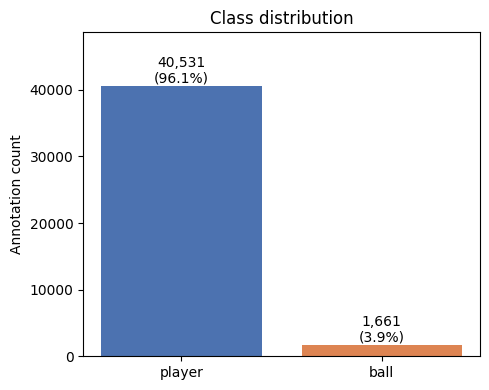


Imbalance ratio (player:ball) = 24.4:1
→ Justifies cls:2.0 upweighting in training config


In [3]:
counts = {name: (classes == cid).sum() for cid, name in CLASS_NAMES.items()}
total = sum(counts.values())

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.keys(), counts.values(),
              color=[CLASS_COLORS[c] for c in CLASS_NAMES])
for bar, (name, count) in zip(bars, counts.items()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{count:,}\n({100*count/total:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_title("Class distribution")
ax.set_ylabel("Annotation count")
ax.set_ylim(0, max(counts.values()) * 1.2)
plt.tight_layout()
plt.show()

print(f"\nImbalance ratio (player:ball) = {counts['player'] / counts['ball']:.1f}:1")
print("→ Justifies cls:2.0 upweighting in training config")

## 3. Bounding Box Size Analysis

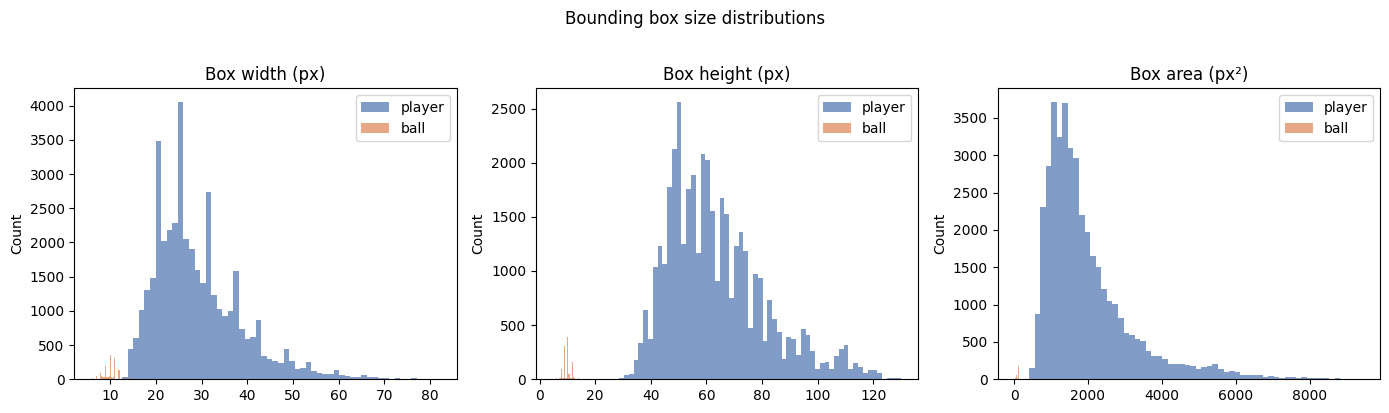

player    median w=27.0px  h=60.0px  area=1624px²
ball      median w=10.0px  h=10.0px  area=100px²

→ Ball boxes are much smaller than player boxes
→ Justifies imgsz=1280 to preserve small object detail


In [4]:
# Sizes are in normalised [0,1] coords — convert to pixels assuming 1920x1080
IMG_W, IMG_H = 1920, 1080

w_px = w * IMG_W
h_px = h * IMG_H
area_px = w_px * h_px

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for cls_id, name in CLASS_NAMES.items():
    mask = classes == cls_id
    color = CLASS_COLORS[cls_id]
    axes[0].hist(w_px[mask], bins=60, alpha=0.7, color=color, label=name)
    axes[1].hist(h_px[mask], bins=60, alpha=0.7, color=color, label=name)
    axes[2].hist(area_px[mask], bins=60, alpha=0.7, color=color, label=name)

axes[0].set_title("Box width (px)")
axes[1].set_title("Box height (px)")
axes[2].set_title("Box area (px²)")
for ax in axes:
    ax.legend()
    ax.set_ylabel("Count")

plt.suptitle("Bounding box size distributions", y=1.02)
plt.tight_layout()
plt.show()

for cls_id, name in CLASS_NAMES.items():
    mask = classes == cls_id
    print(f"{name:8s}  median w={np.median(w_px[mask]):.1f}px  "
          f"h={np.median(h_px[mask]):.1f}px  "
          f"area={np.median(area_px[mask]):.0f}px²")
print("\n→ Ball boxes are much smaller than player boxes")
print("→ Justifies imgsz=1280 to preserve small object detail")

## 4. Dataset Scale and Annotation Density

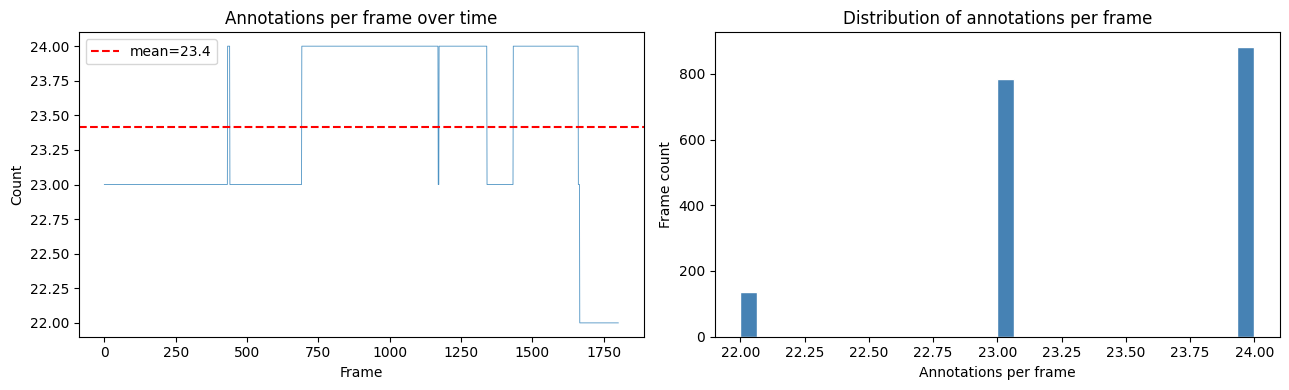

Frames:                1,802
Avg annotations/frame: 23.4
Min annotations/frame: 22
Max annotations/frame: 24


In [5]:
n_frames = len(set(frames))
objs_per_frame = np.array([
    (frames == f).sum() for f in sorted(set(frames))
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Objects per frame over time
axes[0].plot(sorted(set(frames)), objs_per_frame, linewidth=0.6, alpha=0.8)
axes[0].axhline(objs_per_frame.mean(), color="red", linestyle="--",
                label=f"mean={objs_per_frame.mean():.1f}")
axes[0].set_title("Annotations per frame over time")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Count")
axes[0].legend()

# Distribution of annotations per frame
axes[1].hist(objs_per_frame, bins=30, color="steelblue", edgecolor="white")
axes[1].set_title("Distribution of annotations per frame")
axes[1].set_xlabel("Annotations per frame")
axes[1].set_ylabel("Frame count")

plt.tight_layout()
plt.show()

print(f"Frames:                {n_frames:,}")
print(f"Avg annotations/frame: {objs_per_frame.mean():.1f}")
print(f"Min annotations/frame: {objs_per_frame.min()}")
print(f"Max annotations/frame: {objs_per_frame.max()}")

## 5. Ball Visibility (from CVAT XML)

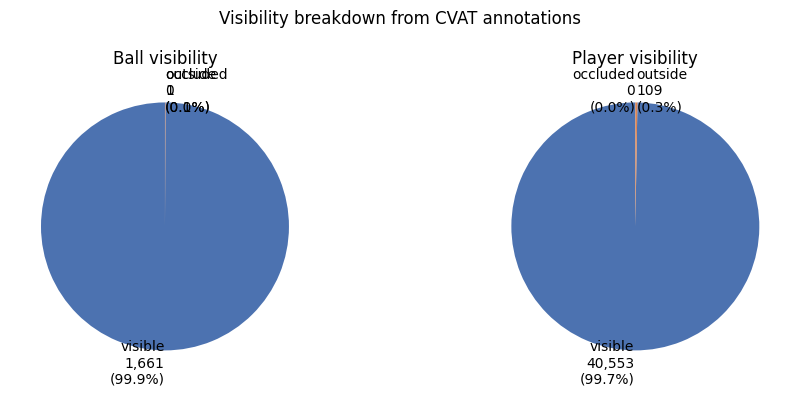

Ball outside frame: 0.1%
Ball occluded:      0.0%
Ball fully visible: 99.9%

→ Ball is frequently absent or occluded — tracking is inherently harder


In [6]:
tree = ET.parse(ANNOTATIONS_XML)
root = tree.getroot()

ball_stats = {"visible": 0, "outside": 0, "occluded": 0}
player_stats = {"visible": 0, "outside": 0, "occluded": 0}

for track in root.findall(".//track"):
    label = track.get("label", "player").lower()
    stats = ball_stats if label == "ball" else player_stats
    for box in track.findall("box"):
        if int(box.get("outside", 0)):
            stats["outside"] += 1
        elif int(box.get("occluded", 0)):
            stats["occluded"] += 1
        else:
            stats["visible"] += 1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, stats) in zip(axes, [("ball", ball_stats), ("player", player_stats)]):
    total = sum(stats.values())
    labels = [f"{k}\n{v:,}\n({100*v/total:.1f}%)" for k, v in stats.items()]
    ax.pie(stats.values(), labels=labels,
           colors=["#4C72B0", "#DD8452", "#55A868"],
           startangle=90)
    ax.set_title(f"{name.capitalize()} visibility")

plt.suptitle("Visibility breakdown from CVAT annotations")
plt.tight_layout()
plt.show()

ball_total = sum(ball_stats.values())
print(f"Ball outside frame: {100*ball_stats['outside']/ball_total:.1f}%")
print(f"Ball occluded:      {100*ball_stats['occluded']/ball_total:.1f}%")
print(f"Ball fully visible: {100*ball_stats['visible']/ball_total:.1f}%")
print("\n→ Ball is frequently absent or occluded — tracking is inherently harder")

## 6. Spatial Heatmaps

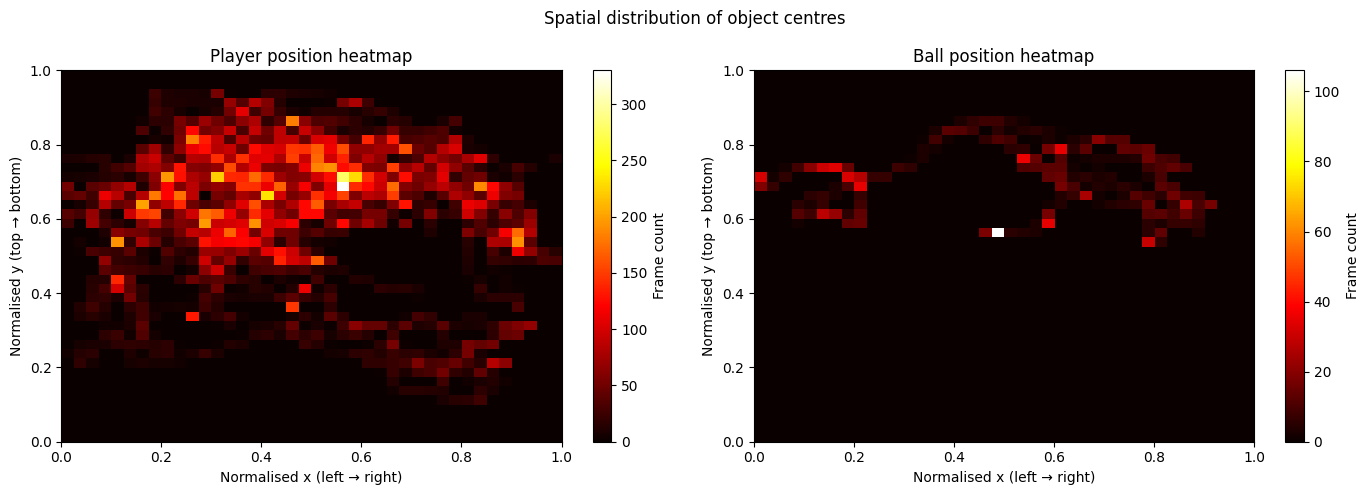

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cls_id, name) in zip(axes, CLASS_NAMES.items()):
    mask = classes == cls_id
    # cx/cy are normalised — plot directly on [0,1] x [0,1]
    h2d, xedges, yedges = np.histogram2d(
        cx[mask], cy[mask], bins=40, range=[[0, 1], [0, 1]]
    )
    im = ax.imshow(
        h2d.T, origin="upper", extent=[0, 1, 0, 1],
        cmap="hot", aspect="auto"
    )
    ax.set_title(f"{name.capitalize()} position heatmap")
    ax.set_xlabel("Normalised x (left → right)")
    ax.set_ylabel("Normalised y (top → bottom)")
    plt.colorbar(im, ax=ax, label="Frame count")

plt.suptitle("Spatial distribution of object centres")
plt.tight_layout()
plt.show()

## 7. Aspect Ratio Analysis

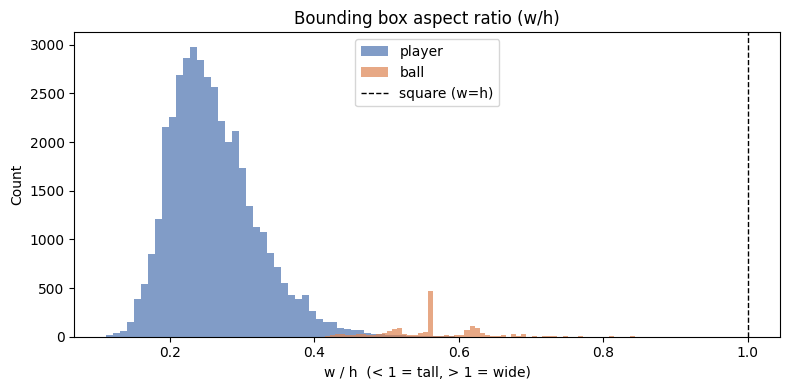

player    median aspect ratio = 0.25
ball      median aspect ratio = 0.56

→ Players are tall (portrait), ball is roughly square
→ Supports using scale/flip augmentation for players


In [8]:
aspect = w / h  # >1 = wide, <1 = tall, =1 = square

fig, ax = plt.subplots(figsize=(8, 4))
for cls_id, name in CLASS_NAMES.items():
    mask = classes == cls_id
    ax.hist(aspect[mask], bins=60, alpha=0.7,
            color=CLASS_COLORS[cls_id], label=name)

ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="square (w=h)")
ax.set_title("Bounding box aspect ratio (w/h)")
ax.set_xlabel("w / h  (< 1 = tall, > 1 = wide)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

for cls_id, name in CLASS_NAMES.items():
    mask = classes == cls_id
    print(f"{name:8s}  median aspect ratio = {np.median(aspect[mask]):.2f}")
print("\n→ Players are tall (portrait), ball is roughly square")
print("→ Supports using scale/flip augmentation for players")

## Summary of EDA Findings

| Finding | Model/Training Decision |
|---|---|
| Ball annotations are ~X% of all annotations | `cls: 2.0` — upweight ball class loss |
| Ball median size ≈ Xpx × Xpx | `imgsz: 1280` — higher resolution preserves small objects |
| Ball outside/occluded X% of frames | Tracking is inherently hard; `track_buffer` tuning needed |
| Players are tall (aspect ~0.4), ball is square (~1.0) | Supports aggressive scale augmentation |